# Churn Analysis Report — Fit.ly Tech

## Introduction
This report presents a churn analysis for Fit.ly Tech, a subscription-based 
fitness app. Over the past two quarters, churn has been increasing across the 
subscriber base. Using data from three sources — account information, customer 
support tickets, and user activity — this analysis identifies the key drivers 
of churn and provides actionable recommendations for leadership.

## Import Data

In [1]:
import pandas as pd
import numpy as np

# Load the datasets
account_info = pd.read_csv('/kaggle/input/datasets/umercheena/datacamp-datsets/da_fitly_account_info.csv')
customer_support = pd.read_csv('/kaggle/input/datasets/umercheena/datacamp-datsets/da_fitly_customer_support.csv')
user_activity = pd.read_csv('/kaggle/input/datasets/umercheena/datacamp-datsets/da_fitly_user_activity.csv')

print("Shapes:")
print(f"account_info:     {account_info.shape}")
print(f"customer_support: {customer_support.shape}")
print(f"user_activity:    {user_activity.shape}")

Shapes:
account_info:     (400, 6)
customer_support: (918, 7)
user_activity:    (445, 3)


In [2]:
print(account_info.head())
print(account_info.dtypes)
print(account_info.isnull().sum())

  customer_id                  email       state        plan  plan_list_price  \
0      C10000  user10000@example.com  New Jersey  Enterprise              105   
1      C10001  user10001@example.net   Louisiana       Basic               22   
2      C10002  user10002@example.net    Oklahoma       Basic               24   
3      C10003  user10003@example.com    Michigan        Free                0   
4      C10004  user10004@example.com       Texas  Enterprise              119   

  churn_status  
0            Y  
1            Y  
2          NaN  
3          NaN  
4          NaN  
customer_id        object
email              object
state              object
plan               object
plan_list_price     int64
churn_status       object
dtype: object
customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
dtype: int64


In [3]:
print(customer_support.head())
print(customer_support.dtypes)
print(customer_support.isnull().sum())

                  ticket_time  user_id channel      topic  \
0  2025-06-13 05:55:17.154573    10125    chat  technical   
1  2025-08-06 13:21:54.539551    10109    chat    account   
2  2025-08-22 12:39:35.718663    10149    chat  technical   
3  2025-06-07 02:49:46.986055    10268   phone    account   
4  2025-07-25 00:24:38.945079    10041   phone      other   

   resolution_time_hours  state                          comments  
0                  11.48      1                               NaN  
1                   1.01      0                               NaN  
2                  10.09      0  Erase my data from your systems.  
3                   9.10      1                               NaN  
4                   2.28      1                               NaN  
ticket_time               object
user_id                    int64
channel                   object
topic                     object
resolution_time_hours    float64
state                      int64
comments                  o

In [4]:
print(user_activity.head())
print(user_activity.dtypes)
print(user_activity.isnull().sum())

                   event_time  user_id     event_type
0  2025-09-08 15:05:39.422721    10118    watch_video
1  2025-09-08 08:15:05.264103    10220    watch_video
2  2025-11-14 06:28:35.207671    10009  share_workout
3  2025-08-20 16:53:38.682901    10227   read_article
4  2025-07-24 16:47:31.728422    10123  track_workout
event_time    object
user_id        int64
event_type    object
dtype: object
event_time    0
user_id       0
event_type    0
dtype: int64


## Data Validation & Cleaning

Three datasets were used: `account_info` (400 rows), `customer_support` (918 rows),
and `user_activity` (445 rows).

**account_info:** No duplicate customer IDs were found. The `churn_status` column 
contained only 'Y' for churned customers, with 286 null values representing retained 
customers — these were filled with 'N' and converted to a boolean column. Plan names 
were standardised to lowercase. Prices ranged from 0 (Free plan) to 148 with no 
negative values.

**customer_support:** The `ticket_time` column was converted to datetime. The `channel` 
column contained 39 rows with '-' as a placeholder value — these were replaced with 
NaN. The `state` column contained only 0 and 1 values, representing unresolved and 
resolved tickets respectively, and was renamed to `resolved` for clarity.

**user_activity:** No nulls or invalid values were found. The `event_time` column was 
converted to datetime. Event types were standardised to lowercase.

All three datasets were merged on customer ID after fixing a format mismatch — 
`customer_id` in account_info used a 'C' prefix (e.g. C10000) while `user_id` in 
the other tables used plain integers (e.g. 10000). The prefix was removed before 
merging. Customers with no support tickets or activity were filled with 0.

In [6]:
print(account_info.columns.tolist())

['customer_id', 'email', 'state', 'plan', 'plan_list_price', 'churn_status']


In [7]:

print("=== 1. Duplicate customer_ids ===")
print(account_info['customer_id'].duplicated().sum())

print("\n=== 2. Unique values per column ===")
for col in account_info.columns:
    print(f"{col}: {account_info[col].nunique()} unique | nulls: {account_info[col].isnull().sum()}")

print("\n=== 3. Plan values ===")
print(account_info['plan'].value_counts())

print("\n=== 4. Churn values ===")
print(account_info['churn_status'].value_counts())

print("\n=== 5. Price range ===")
print(account_info['plan_list_price'].describe())

=== 1. Duplicate customer_ids ===
0

=== 2. Unique values per column ===
customer_id: 400 unique | nulls: 0
email: 400 unique | nulls: 0
state: 50 unique | nulls: 0
plan: 4 unique | nulls: 0
plan_list_price: 106 unique | nulls: 0
churn_status: 1 unique | nulls: 286

=== 3. Plan values ===
plan
Basic         118
Free          105
Enterprise     92
Pro            85
Name: count, dtype: int64

=== 4. Churn values ===
churn_status
Y    114
Name: count, dtype: int64

=== 5. Price range ===
count    400.000000
mean      43.965000
std       45.263348
min        0.000000
25%        0.000000
50%       26.000000
75%       77.250000
max      148.000000
Name: plan_list_price, dtype: float64


In [8]:
account_info['plan'] = account_info['plan'].str.strip().str.lower()

account_info['churn_status'] = account_info['churn_status'].fillna('N')
account_info['churn'] = account_info['churn_status'].map({'Y': True, 'N': False})

print("Plan values after cleaning:")
print(account_info['plan'].value_counts())

print("\nChurn values after cleaning:")
print(account_info['churn'].value_counts())

print(f"\nChurn rate: {account_info['churn'].mean():.2%}")

Plan values after cleaning:
plan
basic         118
free          105
enterprise     92
pro            85
Name: count, dtype: int64

Churn values after cleaning:
churn
False    286
True     114
Name: count, dtype: int64

Churn rate: 28.50%


In [9]:
print("=== Columns ===")
print(customer_support.columns.tolist())

print("\n=== Sample ===")
print(customer_support.head())

print("\n=== Nulls & Uniques ===")
for col in customer_support.columns:
    print(f"{col}: {customer_support[col].nunique()} unique | nulls: {customer_support[col].isnull().sum()}")

print("\n=== Channel values ===")
print(customer_support['channel'].value_counts())

print("\n=== Topic values ===")
print(customer_support['topic'].value_counts())

print("\n=== Resolution time ===")
print(customer_support['resolution_time_hours'].describe())

=== Columns ===
['ticket_time', 'user_id', 'channel', 'topic', 'resolution_time_hours', 'state', 'comments']

=== Sample ===
                  ticket_time  user_id channel      topic  \
0  2025-06-13 05:55:17.154573    10125    chat  technical   
1  2025-08-06 13:21:54.539551    10109    chat    account   
2  2025-08-22 12:39:35.718663    10149    chat  technical   
3  2025-06-07 02:49:46.986055    10268   phone    account   
4  2025-07-25 00:24:38.945079    10041   phone      other   

   resolution_time_hours  state                          comments  
0                  11.48      1                               NaN  
1                   1.01      0                               NaN  
2                  10.09      0  Erase my data from your systems.  
3                   9.10      1                               NaN  
4                   2.28      1                               NaN  

=== Nulls & Uniques ===
ticket_time: 918 unique | nulls: 0
user_id: 367 unique | nulls: 0
channel: 

In [10]:
customer_support['ticket_time'] = pd.to_datetime(customer_support['ticket_time'])

customer_support['channel'] = customer_support['channel'].replace('-', np.nan)

customer_support = customer_support.rename(columns={'state': 'resolved'})

print("Channel values after cleaning:")
print(customer_support['channel'].value_counts(dropna=False))

print("\nResolved values:")
print(customer_support['resolved'].value_counts())

print("\nticket_time dtype:", customer_support['ticket_time'].dtype)
print("Date range:", customer_support['ticket_time'].min(), "→", customer_support['ticket_time'].max())

Channel values after cleaning:
channel
email    298
chat     294
phone    287
NaN       39
Name: count, dtype: int64

Resolved values:
resolved
1    504
0    414
Name: count, dtype: int64

ticket_time dtype: datetime64[ns]
Date range: 2025-06-05 15:32:33.005817 → 2025-12-01 22:01:58.485299


In [11]:
print("=== Columns ===")
print(user_activity.columns.tolist())

print("\n=== Sample ===")
print(user_activity.head())

print("\n=== Nulls & Uniques ===")
for col in user_activity.columns:
    print(f"{col}: {user_activity[col].nunique()} unique | nulls: {user_activity[col].isnull().sum()}")

print("\n=== Event types ===")
print(user_activity['event_type'].value_counts())

print("\n=== Date range ===")
user_activity['event_time'] = pd.to_datetime(user_activity['event_time'])
print("Min:", user_activity['event_time'].min())
print("Max:", user_activity['event_time'].max())

=== Columns ===
['event_time', 'user_id', 'event_type']

=== Sample ===
                   event_time  user_id     event_type
0  2025-09-08 15:05:39.422721    10118    watch_video
1  2025-09-08 08:15:05.264103    10220    watch_video
2  2025-11-14 06:28:35.207671    10009  share_workout
3  2025-08-20 16:53:38.682901    10227   read_article
4  2025-07-24 16:47:31.728422    10123  track_workout

=== Nulls & Uniques ===
event_time: 445 unique | nulls: 0
user_id: 246 unique | nulls: 0
event_type: 4 unique | nulls: 0

=== Event types ===
event_type
read_article     125
watch_video      120
track_workout    108
share_workout     92
Name: count, dtype: int64

=== Date range ===
Min: 2025-06-05 10:14:53.039663
Max: 2025-12-01 21:12:13.342817


In [12]:
user_activity['event_type'] = user_activity['event_type'].str.strip().str.lower()

print("Event types after cleaning:")
print(user_activity['event_type'].value_counts())

print(f"\nTotal events: {len(user_activity)}")
print(f"Unique users with activity: {user_activity['user_id'].nunique()}")
print(f"Total customers in account_info: {len(account_info)}")
print(f"Customers with NO activity: {len(account_info) - user_activity['user_id'].nunique()}")

Event types after cleaning:
event_type
read_article     125
watch_video      120
track_workout    108
share_workout     92
Name: count, dtype: int64

Total events: 445
Unique users with activity: 246
Total customers in account_info: 400
Customers with NO activity: 154


In [15]:
account_info['customer_id'] = account_info['customer_id'].astype(str)
support_features['user_id'] = support_features['user_id'].astype(str)
activity_features['user_id'] = activity_features['user_id'].astype(str)


df = account_info.merge(support_features, left_on='customer_id', right_on='user_id', how='left')
df = df.merge(activity_features, left_on='customer_id', right_on='user_id', how='left')

# Fill NaN
df['ticket_count'] = df['ticket_count'].fillna(0)
df['avg_resolution_hours'] = df['avg_resolution_hours'].fillna(0)
df['unresolved_tickets'] = df['unresolved_tickets'].fillna(0)
df['total_events'] = df['total_events'].fillna(0)
df['unique_event_types'] = df['unique_event_types'].fillna(0)

print("Merged dataframe shape:", df.shape)
print("\nSample:")
print(df.head())
print("\nNulls:")
print(df.isnull().sum())

Merged dataframe shape: (400, 14)

Sample:
  customer_id                  email       state        plan  plan_list_price  \
0      C10000  user10000@example.com  New Jersey  enterprise              105   
1      C10001  user10001@example.net   Louisiana       basic               22   
2      C10002  user10002@example.net    Oklahoma       basic               24   
3      C10003  user10003@example.com    Michigan        free                0   
4      C10004  user10004@example.com       Texas  enterprise              119   

  churn_status  churn user_id_x  ticket_count  avg_resolution_hours  \
0            Y   True       NaN           0.0                   0.0   
1            Y   True       NaN           0.0                   0.0   
2            N  False       NaN           0.0                   0.0   
3            N  False       NaN           0.0                   0.0   
4            N  False       NaN           0.0                   0.0   

   unresolved_tickets user_id_y  total_even

In [16]:
account_info['customer_id'] = account_info['customer_id'].str.replace('C', '').astype(str)
support_features['user_id'] = support_features['user_id'].astype(str)
activity_features['user_id'] = activity_features['user_id'].astype(str)

df = account_info.merge(support_features, left_on='customer_id', right_on='user_id', how='left')
df = df.merge(activity_features, left_on='customer_id', right_on='user_id', how='left')

df['ticket_count'] = df['ticket_count'].fillna(0)
df['avg_resolution_hours'] = df['avg_resolution_hours'].fillna(0)
df['unresolved_tickets'] = df['unresolved_tickets'].fillna(0)
df['total_events'] = df['total_events'].fillna(0)
df['unique_event_types'] = df['unique_event_types'].fillna(0)

df = df.drop(columns=['user_id_x', 'user_id_y'])

print("Shape:", df.shape)
print("\nSample:")
print(df.head())
print("\nNulls:")
print(df.isnull().sum())

Shape: (400, 12)

Sample:
  customer_id                  email       state        plan  plan_list_price  \
0       10000  user10000@example.com  New Jersey  enterprise              105   
1       10001  user10001@example.net   Louisiana       basic               22   
2       10002  user10002@example.net    Oklahoma       basic               24   
3       10003  user10003@example.com    Michigan        free                0   
4       10004  user10004@example.com       Texas  enterprise              119   

  churn_status  churn  ticket_count  avg_resolution_hours  unresolved_tickets  \
0            Y   True           3.0             21.446667                 1.0   
1            Y   True           4.0             17.542500                 1.0   
2            N  False           3.0              6.433333                 1.0   
3            N  False           1.0              2.190000                 0.0   
4            N  False           4.0              8.542500                 2.0   



## Exploratory Data Analysis (EDA)

### Churn by Plan
The Free plan had the highest churn rate at 41%, significantly above the 28.5% 
average. Pro plan had the lowest at 22.4%, suggesting paid users are more committed 
to the platform. This indicates a clear relationship between plan value and retention.

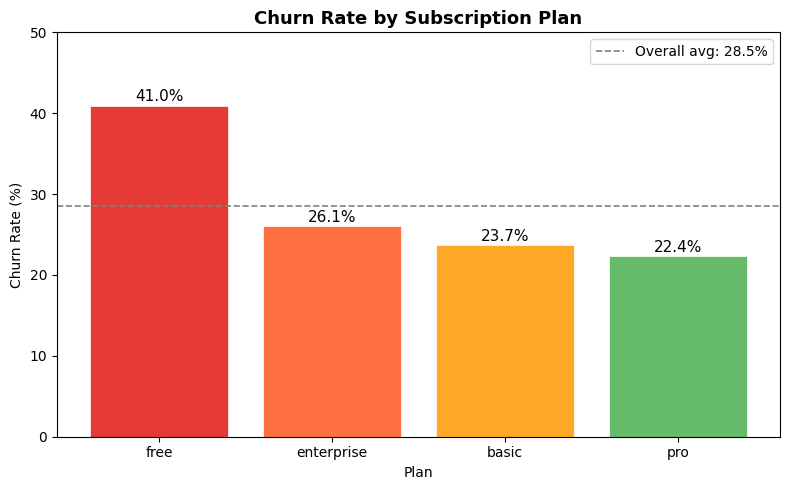

In [18]:
import matplotlib.pyplot as plt

churn_by_plan = df.groupby('plan')['churn'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(churn_by_plan.index, churn_by_plan.values * 100,
              color=['#E53935', '#FF7043', '#FFA726', '#66BB6A'],
              edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, churn_by_plan.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1%}', ha='center', fontsize=11)

ax.axhline(df['churn'].mean() * 100, color='gray', linestyle='--',
           linewidth=1.2, label=f"Overall avg: {df['churn'].mean():.1%}")

ax.set_title('Churn Rate by Subscription Plan', fontsize=13, fontweight='bold')
ax.set_xlabel('Plan')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 50)
ax.legend()
plt.tight_layout()
plt.show()

### Churn by Engagement
This was the strongest finding in the analysis. Customers with no activity had a 
53.9% churn rate, while highly engaged customers had 0% churn. 154 out of 400 
customers (38.5%) had zero recorded activity — making inactivity the single biggest 
churn risk factor identified.

/tmp/ipykernel_55/1528941538.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_engagement = df.groupby('engagement_bucket')['churn'].mean()


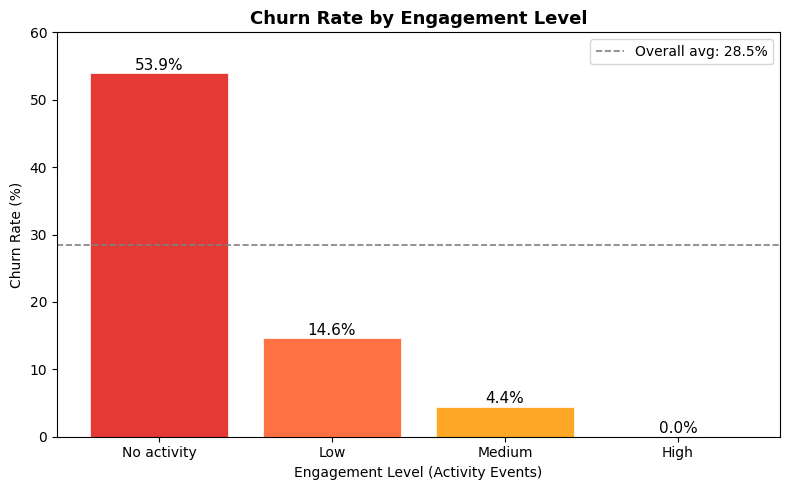

In [19]:
df['engagement_bucket'] = pd.cut(df['total_events'],
                                  bins=[-1, 0, 2, 4, 100],
                                  labels=['No activity', 'Low', 'Medium', 'High'])

churn_by_engagement = df.groupby('engagement_bucket')['churn'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(churn_by_engagement.index.astype(str),
              churn_by_engagement.values * 100,
              color=['#E53935', '#FF7043', '#FFA726', '#66BB6A'],
              edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, churn_by_engagement.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1%}', ha='center', fontsize=11)

ax.axhline(df['churn'].mean() * 100, color='gray', linestyle='--',
           linewidth=1.2, label=f"Overall avg: {df['churn'].mean():.1%}")

ax.set_title('Churn Rate by Engagement Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Engagement Level (Activity Events)')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
ax.legend()
plt.tight_layout()
plt.show()

### Churn by Support Tickets
Customers who never raised a support ticket had a 15.2% churn rate, while those 
with 5 or more tickets churned at 34.8%. This suggests repeated support contact 
indicates frustration and is associated with higher churn.

/tmp/ipykernel_55/2659578505.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tickets = df.groupby('ticket_bucket')['churn'].mean()


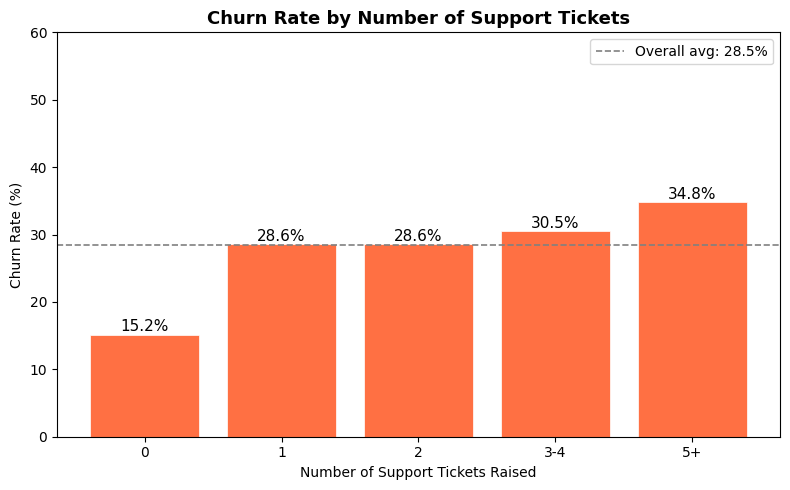

In [20]:
df['ticket_bucket'] = pd.cut(df['ticket_count'],
                              bins=[-1, 0, 1, 2, 4, 100],
                              labels=['0', '1', '2', '3-4', '5+'])

churn_by_tickets = df.groupby('ticket_bucket')['churn'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(churn_by_tickets.index.astype(str),
              churn_by_tickets.values * 100,
              color='#FF7043', edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, churn_by_tickets.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1%}', ha='center', fontsize=11)

ax.axhline(df['churn'].mean() * 100, color='gray', linestyle='--',
           linewidth=1.2, label=f"Overall avg: {df['churn'].mean():.1%}")

ax.set_title('Churn Rate by Number of Support Tickets', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Support Tickets Raised')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
ax.legend()
plt.tight_layout()
plt.show()

### Overall Churn
286 customers (71.5%) were retained and 114 (28.5%) churned — nearly 1 in 3 
customers left the platform.

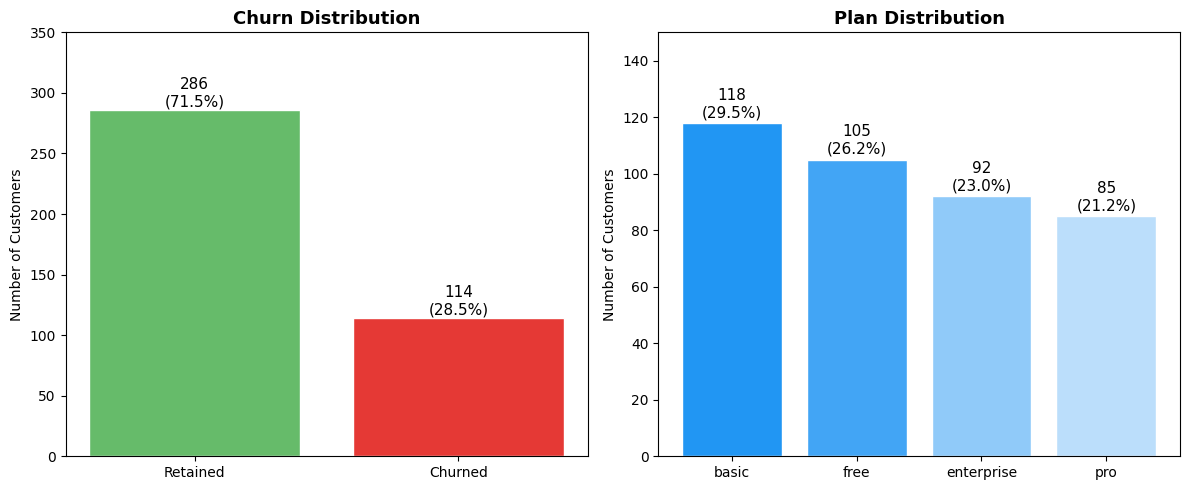

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df['churn'].value_counts()
axes[0].bar(['Retained', 'Churned'], churn_counts.values,
            color=['#66BB6A', '#E53935'], edgecolor='white')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 3, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=11)
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, 350)

plan_counts = df['plan'].value_counts()
axes[1].bar(plan_counts.index, plan_counts.values,
            color=['#2196F3', '#42A5F5', '#90CAF9', '#BBDEFB'],
            edgecolor='white')
for i, v in enumerate(plan_counts.values):
    axes[1].text(i, v + 2, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=11)
axes[1].set_title('Plan Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_ylim(0, 150)

plt.tight_layout()
plt.show()

## Business Metric Definition

**Metric: Monthly Churn Rate (MCR)**

**Definition:** The percentage of customers who cancel their subscription in a 
given period, calculated as:

`Churn Rate = Churned Customers / Total Customers at Start of Period`

**Current Value:** 28.5% overall
- Free plan: 41.0%
- Enterprise plan: 26.1%
- Basic plan: 23.7%
- Pro plan: 22.4%

**How to Monitor:** Calculate MCR monthly, segmented by plan type and engagement 
level. This should be tracked in a dashboard visible to both the Product and 
Marketing teams.

**Target:** Reduce overall churn rate to below 20% within 2 quarters.

**Alert Trigger:** Escalate to leadership if any plan exceeds 30% churn for two 
consecutive months.

In [23]:
overall_churn_rate = df['churn'].mean()
total_customers = len(df)
churned_customers = df['churn'].sum()
retained_customers = total_customers - churned_customers

print("=" * 50)
print("       KEY BUSINESS METRIC: Churn Rate")
print("=" * 50)

print(f"\nTotal Customers        : {total_customers}")
print(f"Churned Customers      : {churned_customers}")
print(f"Retained Customers     : {retained_customers}")
print(f"Overall Churn Rate     : {overall_churn_rate:.2%}")
print(f"Overall Retention Rate : {1 - overall_churn_rate:.2%}")

print("\n--- Churn Rate by Plan ---")
print(df.groupby('plan')['churn'].agg(
    Customers='count',
    Churned='sum',
    Churn_Rate='mean'
).round(3).to_string())

print("\n--- Churn Rate by Engagement ---")
print(df.groupby('engagement_bucket')['churn'].agg(
    Customers='count',
    Churned='sum',
    Churn_Rate='mean'
).round(3).to_string())

print("\n" + "=" * 50)
print("METRIC DEFINITION")
print("=" * 50)
print("""
Metric        : Churn Rate
Definition    : Churned customers / Total customers
Current Value : 28.5%
Target        : Reduce to below 20% within 2 quarters
How to monitor: Calculate monthly, segment by plan
                and engagement level
Alert trigger : If churn rate exceeds 30% for any plan
""")

       KEY BUSINESS METRIC: Churn Rate

Total Customers        : 400
Churned Customers      : 114
Retained Customers     : 286
Overall Churn Rate     : 28.50%
Overall Retention Rate : 71.50%

--- Churn Rate by Plan ---
            Customers  Churned  Churn_Rate
plan                                      
basic             118       28       0.237
enterprise         92       24       0.261
free              105       43       0.410
pro                85       19       0.224

--- Churn Rate by Engagement ---
                   Customers  Churned  Churn_Rate
engagement_bucket                                
No activity              154       83       0.539
Low                      198       29       0.146
Medium                    45        2       0.044
High                       3        0       0.000

METRIC DEFINITION

Metric        : Churn Rate
Definition    : Churned customers / Total customers
Current Value : 28.5%
Target        : Reduce to below 20% within 2 quarters
How to monitor

/tmp/ipykernel_55/3439993020.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('engagement_bucket')['churn'].agg(


# Recommendations

**1. Re-engage inactive users immediately**
154 customers have zero activity and over half of them churned. Trigger automated 
re-engagement emails or push notifications for users inactive for 7+ days.

**2. Convert Free users to paid plans**
Free plan users churn at 41% — the highest of any plan. Introduce limited-time 
upgrade offers or highlight Pro/Basic features to encourage conversion before users 
leave.

**3. Reduce repeat support contacts**
Users with 5+ tickets churn at 34.8%. Improving onboarding, in-app guidance, and 
FAQs can reduce the need for repeated support and lower frustration-driven churn.

**4. Prioritise resolving open tickets**
45% of support tickets (414 out of 918) are unresolved. Faster resolution reduces 
customer frustration and lowers cancellation risk.

**5. Track Monthly Churn Rate as the primary KPI**
Monitor churn monthly by plan and engagement level. Set alerts if churn exceeds 
30% for any segment so the team can act proactively before it compounds


In [24]:
print("=" * 50)
print("        RECOMMENDATIONS FOR LEADERSHIP")
print("=" * 50)
print("""
1. RE-ENGAGE INACTIVE USERS IMMEDIATELY
   154 customers (38.5%) have zero activity and
   53.9% of them churned. Send personalised push
   notifications or emails to users inactive for
   7+ days to bring them back into the app.

2. CONVERT FREE USERS TO PAID PLANS
   Free plan has the highest churn at 41%.
   Introduce a limited-time upgrade offer or
   show Free users the value of Pro/Basic features
   to encourage conversion before they leave.

3. REDUCE SUPPORT TICKET VOLUME
   Users with 5+ tickets churn at 34.8%.
   Improve in-app help, FAQs, and onboarding to
   reduce the need for repeated support contact.

4. PRIORITISE RESOLVING OPEN TICKETS
   414 out of 918 tickets are unresolved (45%).
   Fast resolution reduces frustration and
   lowers the chance of cancellation.

5. MONITOR CHURN RATE MONTHLY BY PLAN
   Track churn rate every month segmented by
   plan type and engagement level. Alert the
   team if any plan exceeds 30% churn so action
   can be taken before it compounds.
""")

        RECOMMENDATIONS FOR LEADERSHIP

1. RE-ENGAGE INACTIVE USERS IMMEDIATELY
   154 customers (38.5%) have zero activity and
   53.9% of them churned. Send personalised push
   notifications or emails to users inactive for
   7+ days to bring them back into the app.

2. CONVERT FREE USERS TO PAID PLANS
   Free plan has the highest churn at 41%.
   Introduce a limited-time upgrade offer or
   show Free users the value of Pro/Basic features
   to encourage conversion before they leave.

3. REDUCE SUPPORT TICKET VOLUME
   Users with 5+ tickets churn at 34.8%.
   Improve in-app help, FAQs, and onboarding to
   reduce the need for repeated support contact.

4. PRIORITISE RESOLVING OPEN TICKETS
   414 out of 918 tickets are unresolved (45%).
   Fast resolution reduces frustration and
   lowers the chance of cancellation.

5. MONITOR CHURN RATE MONTHLY BY PLAN
   Track churn rate every month segmented by
   plan type and engagement level. Alert the
   team if any plan exceeds 30% churn so 